# 02 Repurchase Diagnosis

Goal: quantify repurchase rate and test whether fulfillment delay is associated with repurchase.\n
This notebook reads from `analysis.analysis_user_rfm` and saves key figures under `outputs/figures/`.

## Section 0: Setup

In [6]:
# ======================================================
# Section 0 (Cell 1/1): Setup
# ======================================================
# Requirements (local):
# - Postgres is running and `analysis.analysis_user_rfm` exists
# - DB credentials are provided via env vars (see `.env.example`)
# - Figures will be saved under `outputs/figures/`

import os
import sys
from pathlib import Path
from datetime import datetime, timezone, timedelta

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sqlalchemy import create_engine

try:
    from dotenv import load_dotenv
except Exception:  # pragma: no cover
    load_dotenv = None

if load_dotenv is not None:
    load_dotenv()

# Timezone anchoring for reproducibility
TZ_UTC8 = timezone(timedelta(hours=8))
run_ts_utc8 = datetime.now(TZ_UTC8).strftime('%Y-%m-%d %H:%M:%S %z')
print(f'[UTC+8] Run timestamp: {run_ts_utc8}')

# Project root resolution (avoid hardcoding)
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Figures output
figures_dir = project_root / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
print('Figures will be saved to: /outputs/figures')

# Build engine (prefer DATABASE_URL, fallback to discrete vars)
database_url = os.getenv('DATABASE_URL')
if database_url:
    engine = create_engine(database_url)
else:
    USER = os.getenv('DB_USER')
    PASSWORD = os.getenv('DB_PASS')
    HOST = os.getenv('DB_HOST', 'localhost')
    PORT = os.getenv('DB_PORT', '5432')
    DB = os.getenv('DB_NAME')

    missing = [k for k, v in {'DB_USER': USER, 'DB_PASS': PASSWORD, 'DB_NAME': DB}.items() if not v]
    if missing:
        raise RuntimeError('Missing required env vars (or set DATABASE_URL): ' + ', '.join(missing))

    engine = create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

df_rfm = pd.read_sql('SELECT * FROM analysis.analysis_user_rfm', engine)
assert len(df_rfm) > 0, 'Loaded analysis_user_rfm is empty'

# Basic check
df_rfm.shape, df_rfm.describe()

[UTC+8] Run timestamp: 2026-02-28 21:45:06 +0800
Figures will be saved to: /outputs/figures


((93350, 20),
           frequency      monetary  avg_delay_days  severe_late_rate  \
 count  93350.000000  93350.000000    93350.000000      93350.000000   
 mean       1.033423    165.196388      -11.150558          0.053807   
 std        0.209106    226.322448       10.140914          0.224330   
 min        1.000000      0.000000     -146.016123          0.000000   
 25%        1.000000     63.050000      -16.227124          0.000000   
 50%        1.000000    107.780000      -11.745674          0.000000   
 75%        1.000000    182.547500       -6.392494          0.000000   
 max       15.000000  13664.080000      188.975081          1.000000   
 
        eligible_repurchase_90d  repurchase_within_90d  monetary_90d  \
 count             93350.000000           75385.000000  93350.000000   
 mean                  0.807552               0.012973    163.531332   
 std                   0.394225               0.113160    224.726393   
 min                   0.000000               0.

## Section 1: Repurchase Rate & LTV (90d vs long)

90d窗口复购率(eligible only): 1.30%
Eligible users: 75385/93350
Saved figure: /outputs/figures/fig_02_ltv90_vs_ltvlong.png


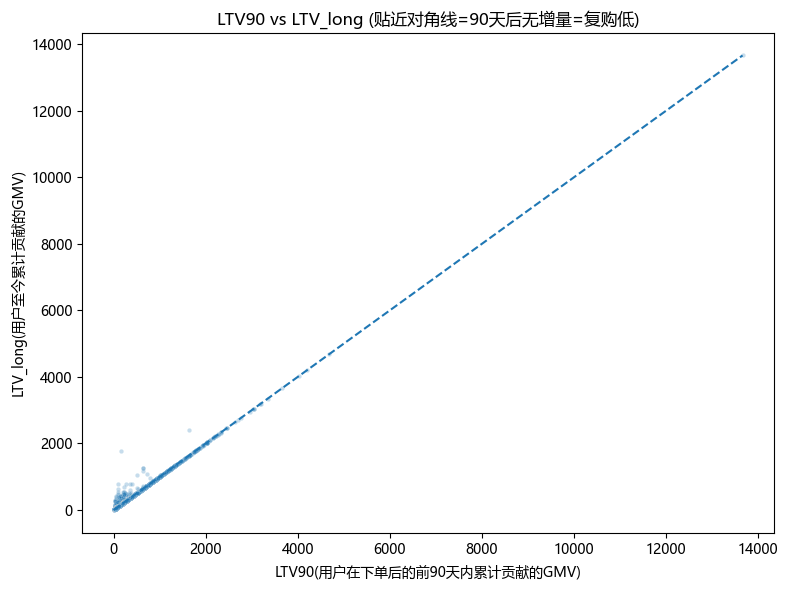

In [7]:
# ======================================================
# Section 1 (Cell 1/1): Repurchase Rate & LTV
# ======================================================
# 逻辑: 通过用户在首单后续是否还有下单来计算复购率,为后续分析做数据准备

# --------------------------
# 1. 复购率计算
# --------------------------
# 90d窗口复购(右删失防御): 仅在 eligible 用户上计算
df_rfm_elig = df_rfm[df_rfm["eligible_repurchase_90d"] == 1].copy()
df_rfm_elig["is_repurchase_90d"] = df_rfm_elig["repurchase_within_90d"].astype("int8")

# 计算核心指标(复购率)
repurchase_rate = df_rfm_elig["is_repurchase_90d"].mean()
churn_rate = 1 - repurchase_rate

print(f"90d窗口复购率(eligible only): {repurchase_rate:.2%}")
print(f"Eligible users: {len(df_rfm_elig)}/{len(df_rfm)}")

# ----------------------------
# 2.LTV数据展示
# ----------------------------
# 避免中文无法正常显示
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]

col_90,col_long = "monetary_90d","monetary_long"
p0 = df_rfm[[col_90, col_long]].dropna()
p = p0.sample(min(20000, len(p0)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=p,x=col_90,y=col_long,s=10,alpha=0.25)

m = p[[col_90, col_long]].to_numpy().max()
plt.plot([0, m], [0, m], "--")  # y=x 参考线
plt.title("LTV90 vs LTV_long (贴近对角线=90天后无增量=复购低)")
plt.xlabel("LTV90(用户在下单后的前90天内累计贡献的GMV)")
plt.ylabel("LTV_long(用户至今累计贡献的GMV)")
plt.tight_layout()
fig = plt.gcf()
out_path = figures_dir / 'fig_02_ltv90_vs_ltvlong.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved figure: /outputs/figures/{out_path.name}")
plt.show()


### Section 1 Summary

**Workflow**:
- 用 90d 窗口复购（`eligible_repurchase_90d=1` 且 `repurchase_within_90d`）标记复购用户，并计算复购率。
- 用 `monetary_90d` vs `monetary_long` 的散点图，把用户的短期价值与长期价值放在同一个坐标系里，直观看 90 天后是否还有增量消费。

**Core Figures (from output)**:
- 复购率口径采用 **90d窗口复购**（eligible only），避免数据集尾部用户被右删失低估复购。
- `monetary_90d` / `monetary_long` 的均值非常接近（`163.53` vs `165.20`），说明大部分用户生命周期价值集中在首单后 90 天内，90 天后增量有限。
- 分布长尾明显：`monetary_long` 最大值 `13664.08`，因此用均值看增长很容易被少量大客户拉高，需要配合分位数/分层分析。

**Insights**:
- 对多数用户来说，LTV90 与 LTV_long 贴近对角线，意味着复购更多是“是否发生”而不是“发生很多次”。
- 在这种低复购平台里，增长策略不能默认高频复购驱动；更合理的目标是：降低流失、提升首单体验、提高少量优质用户的长期贡献。

**Business Translation**:
- **增长动作优先级**：先保证履约/体验底线（避免差评与退款导致的永久流失），再谈复购刺激。
- **指标落地**：把 `LTV90` 当作“短期质量”的 proxy，把 `LTV_long - LTV90` 当作“长期增量”的 proxy，用于评估拉新渠道/品类的质量。

**Artifacts**:
- 已保存图表: `/outputs/figures/fig_02_ltv90_vs_ltvlong.png`


## Section 2: Fulfillment Delay Attribution (T-test + state stratification)


 1. 整体T-Test检验
平均延迟天数 (流失组): -10.91 days
平均延迟天数 (复购组): -11.57 days
检验P值: 6.0158e-03 (显著)

 2. (MG)分层T-Test检验
平均延迟天数 (流失组): -12.22 days
平均延迟天数 (复购组): -13.04 days
检验P值: 1.8727e-01 (不显著)
Saved figure: /outputs/figures/fig_02_top3_state_delay_by_repurchase.png


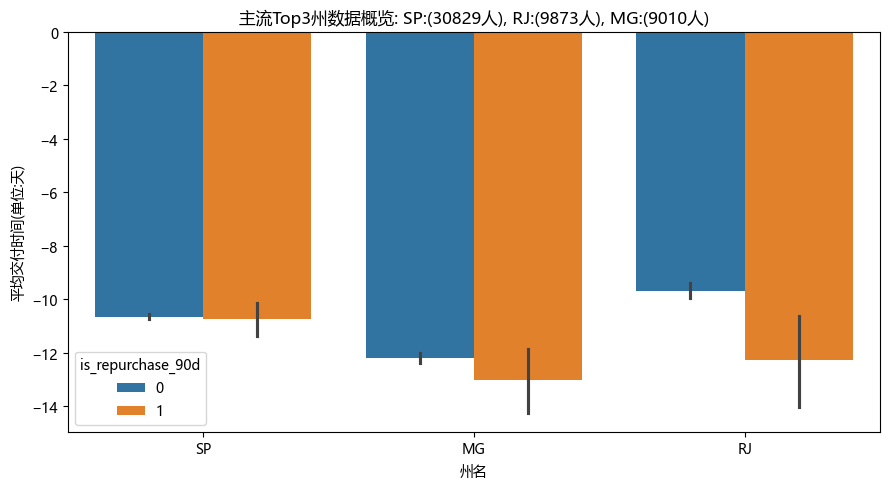

In [8]:
# ======================================================
# Section 2 (Cell 1/1): Fulfillment Delay Attribution
# ======================================================

# ---------------------------
# 1. 整体T-Test(基础)
# ---------------------------
# 把用户分成两组:复购组,流失组
group_repurchase = df_rfm_elig[df_rfm_elig["is_repurchase_90d"] == 1]["avg_delay_days"].dropna()
group_churned = df_rfm_elig[df_rfm_elig["is_repurchase_90d"] == 0]["avg_delay_days"].dropna()

# 做两独立样本均值差异检验
t_stat, p_val = stats.ttest_ind(group_churned, group_repurchase, equal_var=False)

print(f"\n 1. 整体T-Test检验")
print(f"平均延迟天数 (流失组): {group_churned.mean():.2f} days")
print(f"平均延迟天数 (复购组): {group_repurchase.mean():.2f} days")
print(f"检验P值: {p_val:.4e} ({'显著' if p_val < 0.05 else '不显著'})")


# -----------------------------
# 2. 分层T-Test(深层)
# -----------------------------
# 解决问题:流失用户延迟高,是不是因为所在地区本来就远、本来就更容易流失,而不是延迟导致的
# 逻辑:在同一个州内部进行T-Test(以"MG"为例子),查看延迟差异是否显著
#      如果在同一个州中,两个组的平均交付时间差异仍显著,则证明物流是独立影响因素而非半生现象
state = 'MG'
test_state = df_rfm_elig[df_rfm_elig["primary_state"] == state]

#test_state = df_rfm[df_rfm["primary_state"] == 'SP']

group_state_repurchase = test_state[test_state["is_repurchase_90d"] == 1]["avg_delay_days"].dropna()
group_state_churned  = test_state[test_state["is_repurchase_90d"] == 0]["avg_delay_days"].dropna()

t_stat, p_val = stats.ttest_ind(group_state_churned, group_state_repurchase, equal_var=False)

print(f"\n 2. ({state})分层T-Test检验")
print(f"平均延迟天数 (流失组): {group_state_churned.mean():.2f} days")
print(f"平均延迟天数 (复购组): {group_state_repurchase.mean():.2f} days")
print(f"检验P值: {p_val:.4e} ({'显著' if p_val < 0.05 else '不显著'})")


# --------------------------------
# 3. 所有主流州数据概况
# --------------------------------
# 逻辑:给出用户数最多的Top3州数据概览
# 按用户数计算得出Top3 primary_state
top3_counts = (
    df_rfm_elig["primary_state"]
    .dropna()
    .value_counts()
    .head(3)
)

# Top3州
top3_states = top3_counts.index.to_list()
# 每个州对应的用户数
top3_user_counts = top3_counts.to_dict()

df_top3 = df_rfm_elig[df_rfm_elig["primary_state"].isin(top3_states)]
plt.figure(figsize=(9, 5))
sns.barplot(
    x='primary_state',
    y='avg_delay_days',
    hue='is_repurchase_90d',
    data=df_top3,
    # 95%置信区间
    errorbar=("ci",95)
)
plt.xlabel('州名')
plt.ylabel('平均交付时间(单位:天)')
plt.title('主流Top3州数据概览: ' + ', '.join([f"{s}:({top3_user_counts[s]}人)" for s in top3_states]))
plt.tight_layout()
fig = plt.gcf()
out_path = figures_dir / 'fig_02_top3_state_delay_by_repurchase.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
print(f"Saved figure: /outputs/figures/{out_path.name}")
plt.show()

### Section 2 Summary

**Workflow**:
- 用 Welch's T-test (`equal_var=False`) 比较复购组 vs 流失组在 `avg_delay_days` 上的均值差异。
- 做州内分层（示例：`primary_state='MG'`），用同一个州内的对比来弱化地理距离/基础设施差异带来的混淆。
- 用 Top3 州的分组条形图做 sanity check，确保整体结论不是单一州样本主导。

**Core Figures (from output)**:
- 整体：流失组 `-10.91` days vs 复购组 `-11.57` days，`p=6.0158e-03`（显著）。
- MG 州内：流失组 `-12.22` days vs 复购组 `-13.04` days，`p=1.8727e-01`（不显著）。
- 注意：两组均值为负，说明在该数据集里‘平均来说更偏向提前/准时送达’，但复购组更偏向‘更早交付’。

**Insights (what an interviewer will probe)**:
- **总体显著、分层不显著** 是典型‘构成效应/混淆’信号：州分布差异可能驱动了总体均值差。
- **统计显著 ≠ 业务显著**：整体均值差异不到 1 天，在 N 很大时容易显著；需要补充效应大小（Cohen's d）、分位数差异、以及 `Late_Severe` 这类非线性风险指标。
- **分布与异常值**：`avg_delay_days` 长尾明显，T-test 对分布假设较敏感；可以补充 Mann-Whitney U / bootstrap CI / winsorize 做稳健性。

**Business Translation**:
- 不把‘延迟均值差’直接讲成因果：更像是需要进一步分层与控制变量的风险信号。
- 更强归因：建一个 `is_repurchase_90d` 的 logit/GLM（控制 `primary_state`, `monetary`, `category mix`, `severe_late_rate` 等），或做 matching 得到更可辩护的对照。

**Artifacts**:
- 已保存图表: `/outputs/figures/fig_02_top3_state_delay_by_repurchase.png`
